# Data Mining Assignment 5 - Izaak King, kingi@rpi.edu
Attached is my submission for assignment 5.

## Data preparation

We first parse our given Breast Cancer Wisconsin (Diagnostic) dataset into a data matrix. ID variable isn't used, and Diagnosis variable will be used later to determine the ground truth clustering. The remaining data matrix, 569 x 30 will be scaled with sklearn's MinMaxScalar.

In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy.special import logsumexp
from sklearn.metrics import normalized_mutual_info_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt



rawData = pd.read_csv("wdbc.data")          # Use Pandas Library to parse inital data file, store in Data frame
diagnosisData = (rawData.iloc[ : , 1]).to_numpy()          #The Second column is the Diagosis Variable
dataMatrix = (rawData.iloc[ : , 2: ]).to_numpy()           # Columns 3-32 are saved and added created into a Data Matrix using NumPy. Column 1, Patient ID, is disregarded.
scaler = MinMaxScaler(feature_range=(0, 1))                # Use sklearn's MinMaxScaler
scaledDataMatrix = scaler.fit_transform(dataMatrix)

## DENCLUE Algorithm
We first implement the DENCLUE density-based clustering algorithm, slightly modified from that in the book. We will use mean-shift updates to compute the attractor for each point. We implement the Gaussian Kernel function which we can call while finding the attractor. Another difference is within our modified algorithm we will not do any density-based filtering. We will compare a point xi's computed attractor ai with all other found attractors ak. If |ai - ak| <= theta, for some specified theta, we will add xi to ak's point set. While doing this, we will update the attractor to be the mean of the two attractors, using a running mean update. Finally, we will run Sklearn's kmeans algorithm to assign points to a specified num_cluster number of clusters. We return our sets of clusters.

In [36]:
# Gaussian Kernel Function
def K(x, xi, h):    
    diff = x - xi
    exponent = - (np.dot(diff, diff)/(2 * h**2))
    d = xi.shape[0]
    denom = (2 * np.pi) ** (d/2)
    return (1 / denom) * np.exp(exponent)


# FindAttractor helper function
def FindAttractor(x, D, h, epsi):
    x_t = np.copy(x)
    while True:
        numerator = np.zeros_like(x_t)
        denominator = 0

        for xi in D:   # Loop over all points in D
            
            w = K(x_t, xi, h)          # weight of xi based on our Kernel function
            numerator += w * xi
            denominator += w

        x_next = numerator / denominator
        if np.linalg.norm(x_next - x_t) <= epsi:  # Check convergence
            break

        x_t = x_next

    return x_t


'''
Modified DENCLUE algorithm for Density Based Clustering

Parameters:
    D- the dataset
    h- the bandwitch for kernel
    epsi- the convergence threshold for mean-shift 
    theta- the distance threshold for attractor closeness test
    num_clusters - the number of clusters we will return

Output:
    clusters- The set of clusters of data points, as derived from our algorithm
'''

def DENCLUE(D, h, epsi, theta, num_clusters):
    A =  {} # Dictionary holds an index as key, with corresponding attractor, attractor points, and point count as values
    A_index = 0
    
    for i, x in enumerate(D): # Walk through each point in our dataset
        
        a_i = FindAttractor(x, D, h, epsi)
        merged = False    # Merge value indicates if our attractor has been added to another

        for A_k in A.keys():   # Walk through each current attractor in A, merging a_i if it's close enough to another attractor
            dist = np.linalg.norm(a_i - A[A_k]["center"])
            if dist <= theta:
                new_center = (A[A_k]["center"] * A[A_k]["count"] + a_i) / (A[A_k]["count"] + 1)  # Use running mean for updating
                A[A_k]["center"] = new_center
                A[A_k]["points"].append(x)
                A[A_k]["count"] += 1
                merged = True
                break

        if not merged:  # If our point remains unmerged we add it to the dictionary A
            A[A_index] = {"center": a_i, "points": [x], "count": 1}
            A_index += 1

    
    centers = []    # Append the centers of each attractor to a set to run K Means for clustering
    for A_k in A.keys():
        centers.append(A[A_k]["center"])

    
    kmeans = KMeans(n_clusters = num_clusters).fit(centers)  # Use scikit KMeans to perform clustering into num_clusters clusters
    attractor_labels = kmeans.labels_

    clusters = {k: [] for k in range(num_clusters)}     # Assign each point to their corresponding cluster, which we will return 
    for i, A_k in enumerate(list(A.keys())):
        label = attractor_labels[i]
        clusters[label].extend(A[A_k]["points"])

    return clusters

## Applying DENCLUE
We now apply our DENCLUE function to our UCI Breast Cancer Dataset. We use a range of h values and theta values, comparing NMI score to see what performs best for 2 clusters. We print the best performing parameters, and will use these to plot our clusters using the PCA projections.

In [37]:
import numpy as np
from sklearn.metrics import normalized_mutual_info_score


h_values = [0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3]        # range of h, the bandwidths
theta_values = [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.02]   # range of thetas, the attractor merge thresholds
epsi = 1e-6
num_clusters = 2 

best_nmi = -1
best_params = {}
best_clusters = None

for h in h_values:
    for theta in theta_values:
        clusters = DENCLUE(scaledDataMatrix, h, epsi, theta, num_clusters)    # Run DENCLUE
    
        pred_labels = np.zeros(len(scaledDataMatrix), dtype=int)  # Put clusters into labels array
        for k, points in clusters.items():
            for p in points:
                i = np.where(np.all(scaledDataMatrix == p, axis=1))[0][0]  # find the index of this point `p` in the original dataset
                pred_labels[i] = k
        
        nmi = normalized_mutual_info_score(diagnosisData, pred_labels, average_method='geometric')  # Compute NMI

        if nmi > best_nmi:   # If these values for h and theta work best we store them
            best_nmi = nmi
            best_params = {'h': h, 'theta': theta}
            best_clusters = clusters

print("\nBest parameters:")
print(best_params)
print(f"Best NMI: {best_nmi:.4f}")

print("Cluster sizes for best clustering:")
for k, points in best_clusters.items():
    print(f"Cluster {k}: {len(points)} points")



Best parameters:
{'h': 0.1, 'theta': 0.0005}
Best NMI: 0.6356
Cluster sizes for best clustering:
Cluster 0: 174 points
Cluster 1: 394 points


## Plotting Clusters
Now, with the best performing parameters and their corresponding clusters, we apply the PCA projections to plot our data, including the centers of each cluster with an marker.

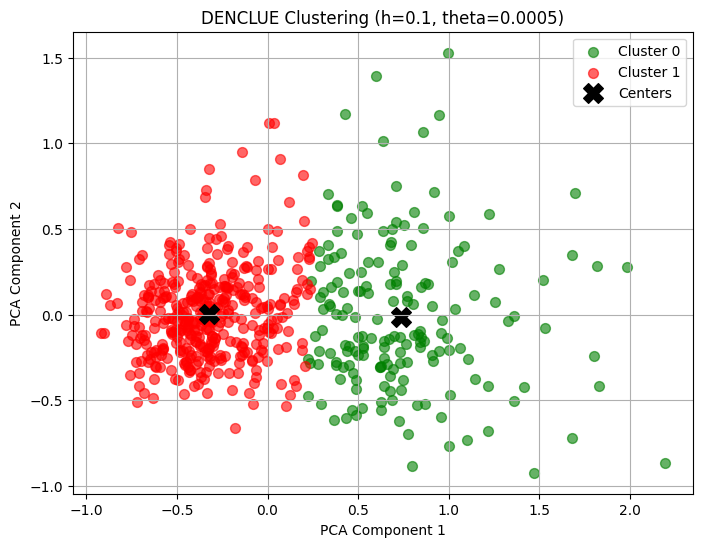

In [40]:
all_points = []
all_labels = []

for k, points in best_clusters.items():   # Add all cluster points into arrays for PCA
    for p in points:
        all_points.append(p)
        all_labels.append(k)

all_points = np.array(all_points)
all_labels = np.array(all_labels)

pca = PCA(n_components=2)  # PCA to reduce to 2D
points_2d = pca.fit_transform(all_points)

cluster_centers = []    # Compute cluster centers in PCA space
for k in np.unique(all_labels):
    cluster_points = points_2d[all_labels == k]
    center = cluster_points.mean(axis=0)
    cluster_centers.append(center)
cluster_centers = np.array(cluster_centers)

colors = ['green', 'red']  
plt.figure(figsize=(8, 6))

for k in np.unique(all_labels):  # Plot clusters
    cluster_points = points_2d[all_labels == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                s=50, c=colors[k % len(colors)], label=f'Cluster {k}', alpha=0.6)

plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1],   # Plot cluster centers
            s=200, c='black', marker='X', label='Centers')

plt.title(f"DENCLUE Clustering (h={best_params['h']}, theta={best_params['theta']})")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()
